# Every log-log plot is a straight line, and I'm tired of pretending it isn't

This notebook compares three positive models under additive Gaussian noise: a true power law, an exponential curve, and a cubic polynomial. The goal is practical rather than rhetorical: show when log-log straightness is theoretically justified, and when it only looks persuasive over a limited range. All cases use the same visual protocol so the comparison is fair.

---
Filipe Borges
f3l5p7@yahoo.com.br


In [55]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

try:
    plt.style.use("../style/myStyle.mplstyle")
except OSError:
    plt.style.use("style/myStyle.mplstyle")

SAVEFIG_KW = {"dpi": 300, "bbox_inches": "tight", "facecolor": "white"}

def resolve_assets_dir():
    cwd = Path.cwd().resolve()
    if cwd.name == "notebooks" and (cwd.parent / "assets").exists():
        return cwd.parent / "assets"
    if (cwd / "assets").exists():
        return cwd / "assets"
    if (cwd.parent / "assets").exists():
        return cwd.parent / "assets"
    return cwd / "assets"

def save_figure(fig, out_path):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, **SAVEFIG_KW)
    return out_path

def linear_fit_xy(x, y):
    m, b = np.polyfit(x, y, 1)
    y_fit = m * x + b
    ss_res = np.sum((y - y_fit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1.0 - ss_res / ss_tot
    return m, b, y_fit, r2

def linear_fit_loglog(x, y):
    logx = np.log10(x)
    logy = np.log10(y)
    m, b = np.polyfit(logx, logy, 1)
    y_fit = 10 ** b * x ** m
    logy_fit = m * logx + b
    ss_res = np.sum((logy - logy_fit) ** 2)
    ss_tot = np.sum((logy - np.mean(logy)) ** 2)
    r2 = 1.0 - ss_res / ss_tot
    return m, b, y_fit, r2

def plot_case_fit_figure(x, y_true, y_noisy, case_title):
    _, _, y_fit_lin, r2_lin = linear_fit_xy(x, y_noisy)
    _, _, y_fit_log, r2_log = linear_fit_loglog(x, y_noisy)
    fig, axes = plt.subplots(2, 2, figsize=(11.0, 7.2))

    axes[0, 0].scatter(x, y_noisy, s=14, alpha=0.75, color="black", label="Noisy data")
    axes[0, 0].plot(x, y_true, color="0.4", label="True model")
    axes[0, 0].set_title("Linear axes")
    axes[0, 0].set_xlabel("x")
    axes[0, 0].set_ylabel("y")
    axes[0, 0].legend(loc="best")

    axes[0, 1].scatter(x, y_noisy, s=14, alpha=0.75, color="black", label="Noisy data")
    axes[0, 1].plot(x, y_true, color="0.4", label="True model")
    axes[0, 1].set_xscale("log")
    axes[0, 1].set_yscale("log")
    axes[0, 1].set_title("Log-log axes")
    axes[0, 1].set_xlabel("x")
    axes[0, 1].set_ylabel("y")
    axes[0, 1].legend(loc="best")

    axes[1, 0].scatter(x, y_noisy, s=14, alpha=0.75, color="black", label="Noisy data")
    axes[1, 0].plot(x, y_fit_lin, color="red", linestyle="--", linewidth=2.0, label=f"Linear fit (R2={r2_lin:.3f})")
    axes[1, 0].set_title("Linear axes + linear fit")
    axes[1, 0].set_xlabel("x")
    axes[1, 0].set_ylabel("y")
    axes[1, 0].legend(loc="best")

    axes[1, 1].scatter(x, y_noisy, s=14, alpha=0.75, color="black", label="Noisy data")
    axes[1, 1].plot(x, y_fit_log, color="red", linestyle="--", linewidth=2.0, label=f"Log-log linear fit (R2={r2_log:.3f})")
    axes[1, 1].set_xscale("log")
    axes[1, 1].set_yscale("log")
    axes[1, 1].set_title("Log-log axes + linear fit in log-space")
    axes[1, 1].set_xlabel("x")
    axes[1, 1].set_ylabel("y")
    axes[1, 1].legend(loc="best")

    fig.suptitle(case_title, y=1.01)
    fig.tight_layout()
    return fig

def plot_summary_figure(summary_cases):
    fig_summary, axes = plt.subplots(2, 3, figsize=(12.5, 7.0))
    for j, (name, x_case, y_true_case, y_noisy_case) in enumerate(summary_cases):
        _, _, y_fit_lin, r2_lin = linear_fit_xy(x_case, y_noisy_case)
        _, _, y_fit_log, r2_log = linear_fit_loglog(x_case, y_noisy_case)
        axes[0, j].scatter(x_case, y_noisy_case, s=12, alpha=0.75, color="black", label="Noisy data")
        axes[0, j].plot(x_case, y_true_case, color="0.4", label="True model")
        axes[0, j].plot(x_case, y_fit_lin, color="red", linestyle="--", linewidth=2.2, label=f"Linear fit (R2={r2_lin:.3f})")
        axes[0, j].set_title(name)
        axes[0, j].set_xlabel("x")
        axes[0, j].set_ylabel("y")
        axes[0, j].legend(loc="best")
        axes[1, j].scatter(x_case, y_noisy_case, s=12, alpha=0.75, color="black", label="Noisy data")
        axes[1, j].plot(x_case, y_true_case, color="0.4", label="True model")
        axes[1, j].plot(x_case, y_fit_log, color="red", linestyle="--", linewidth=2.2, label=f"Log-log fit (R2={r2_log:.3f})")
        axes[1, j].set_xscale("log")
        axes[1, j].set_yscale("log")
        axes[1, j].set_xlabel("x")
        axes[1, j].set_ylabel("y")
        axes[1, j].legend(loc="best")
    fig_summary.tight_layout()
    return fig_summary

def export_notebook_to_html(notebook_path=None, html_name="loglog_illusion.html"):
    import nbformat
    from nbconvert import HTMLExporter
    if notebook_path is None:
        notebooks = sorted(Path.cwd().glob("*.ipynb"))
        if len(notebooks) == 1:
            notebook_path = notebooks[0]
        elif len(notebooks) == 0:
            raise FileNotFoundError("No .ipynb file found in current directory. Pass notebook_path explicitly.")
        else:
            raise ValueError("Multiple .ipynb files found in current directory. Pass notebook_path explicitly.")
    notebook_path = Path(notebook_path)
    if not notebook_path.exists():
        raise FileNotFoundError(f"Notebook not found: {notebook_path}")
    with notebook_path.open("r", encoding="utf-8") as f:
        nb_node = nbformat.read(f, as_version=4)
    exporter = HTMLExporter()
    exporter.exclude_input_prompt = True
    exporter.exclude_output_prompt = True
    body, _ = exporter.from_notebook_node(nb_node)
    html_path = notebook_path.with_name(html_name)
    html_path.write_text(body, encoding="utf-8")
    return html_path

def generate_plot_figures(notebook_path=None, export_html=True, html_name="loglog_illusion.html"):
    assets_dir = resolve_assets_dir()
    fig_power = plot_case_fit_figure(x_power, y_true_power, y_noisy_power, "Case A: True power law")
    fig_exp = plot_case_fit_figure(x_exp, y_true_exp, y_noisy_exp, "Case B: Exponential")
    fig_cubic = plot_case_fit_figure(x_cubic, y_true_cubic, y_noisy_cubic, "Case C: Cubic polynomial")
    summary_cases = [("Power law", x_power, y_true_power, y_noisy_power), ("Exponential", x_exp, y_true_exp, y_noisy_exp), ("Cubic polynomial", x_cubic, y_true_cubic, y_noisy_cubic)]
    fig_summary = plot_summary_figure(summary_cases)
    powerlaw_png = save_figure(fig_power, assets_dir / "loglog_powerlaw_fit.png")
    exponential_png = save_figure(fig_exp, assets_dir / "loglog_exponential_fit.png")
    cubic_png = save_figure(fig_cubic, assets_dir / "loglog_cubic_fit.png")
    summary_png = save_figure(fig_summary, assets_dir / "loglog_summary_cases.png")
    plt.close(fig_power); plt.close(fig_exp); plt.close(fig_cubic); plt.close(fig_summary)
    html_path = export_notebook_to_html(notebook_path=notebook_path, html_name=html_name) if export_html else None
    return {"powerlaw_png": powerlaw_png, "exponential_png": exponential_png, "cubic_png": cubic_png, "summary_png": summary_png, "html": html_path}


In [56]:
# Utility functions are defined in the previous cell.


## Case A: Power law

For a true power law, $y=C_1x^{\alpha}+\varepsilon$, a log-log transform is theoretically aligned with the model class because $\log y$ is affine in $\log x$ when noise is small relative to the signal. Parameters are chosen so values remain positive without clipping or re-sampling.


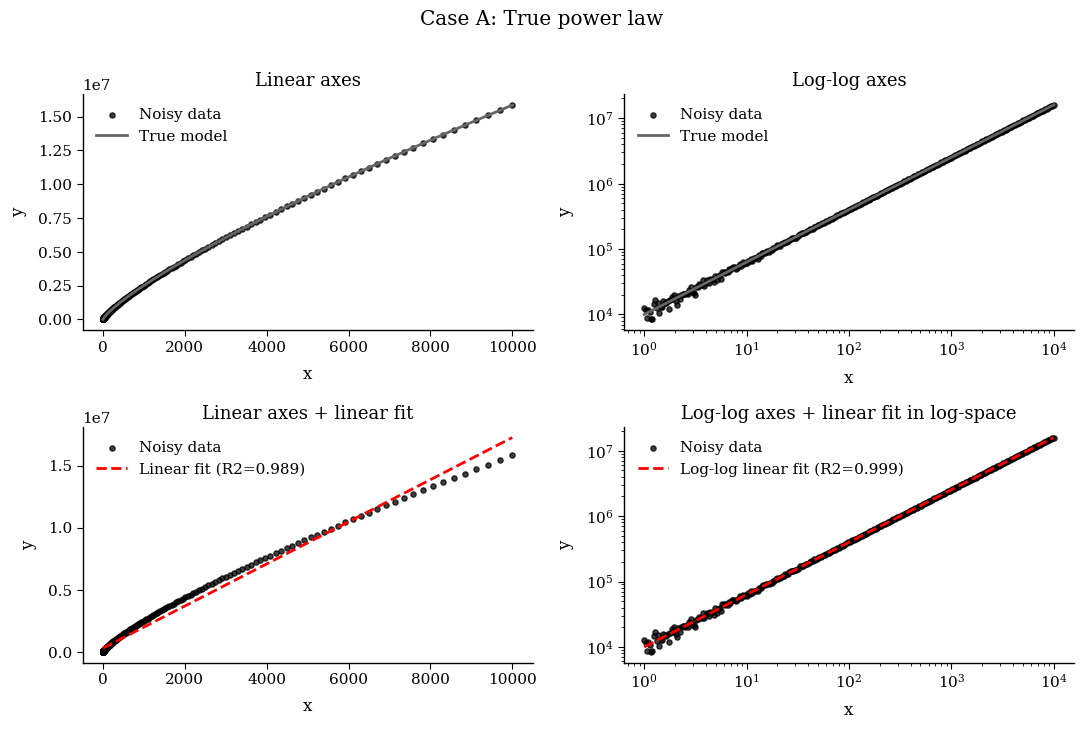

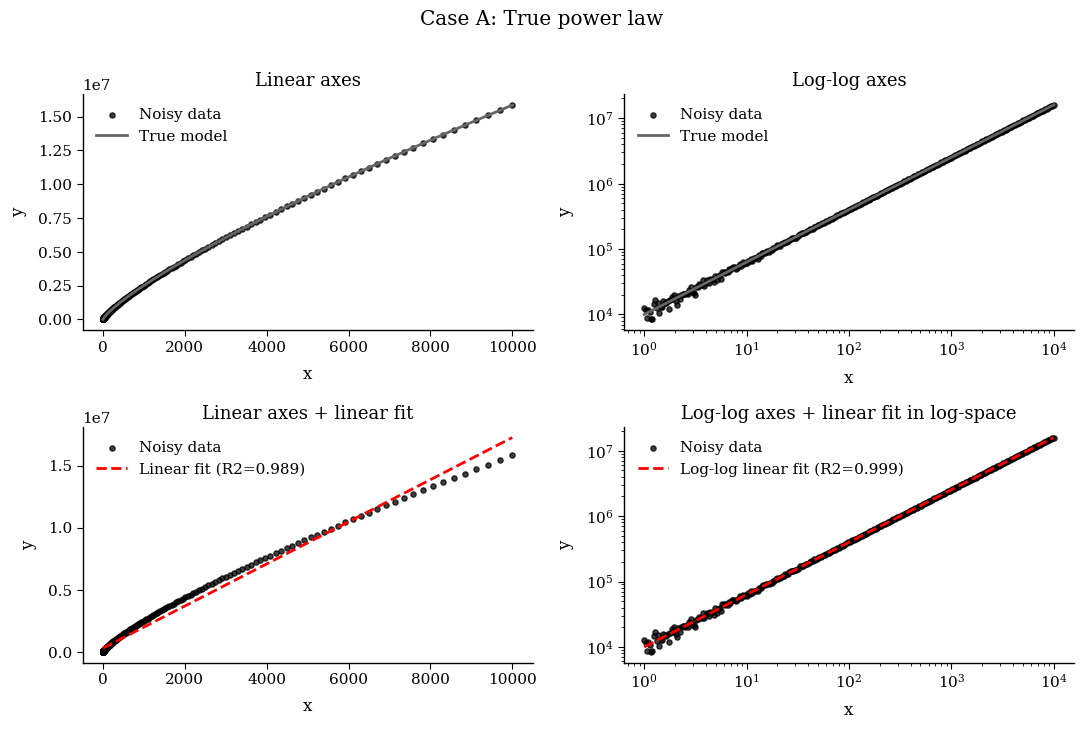

In [57]:
rng = np.random.default_rng(20260310)
x_power = np.logspace(0, 4, 300)
C1 = 1e4
alpha = 0.8
y_true_power = C1 * x_power**alpha
sigma_power = 0.22 * y_true_power.min()
assert np.all(y_true_power - 4 * sigma_power > 0)
eps_power = rng.normal(0.0, sigma_power, size=x_power.size)
y_noisy_power = y_true_power + eps_power
assert np.all(y_noisy_power > 0)
fig_power = plot_case_fit_figure(x_power, y_true_power, y_noisy_power, "Case A: True power law")
display(fig_power)


## Case B: Exponential

Here the deterministic model is exponential, $y=A\exp(kx_{\mathrm{scaled}})+\varepsilon$, which is exactly linear in semi-log coordinates, not in log-log coordinates. Over finite ranges, the log-log panel can still look deceptively straighter than it should.


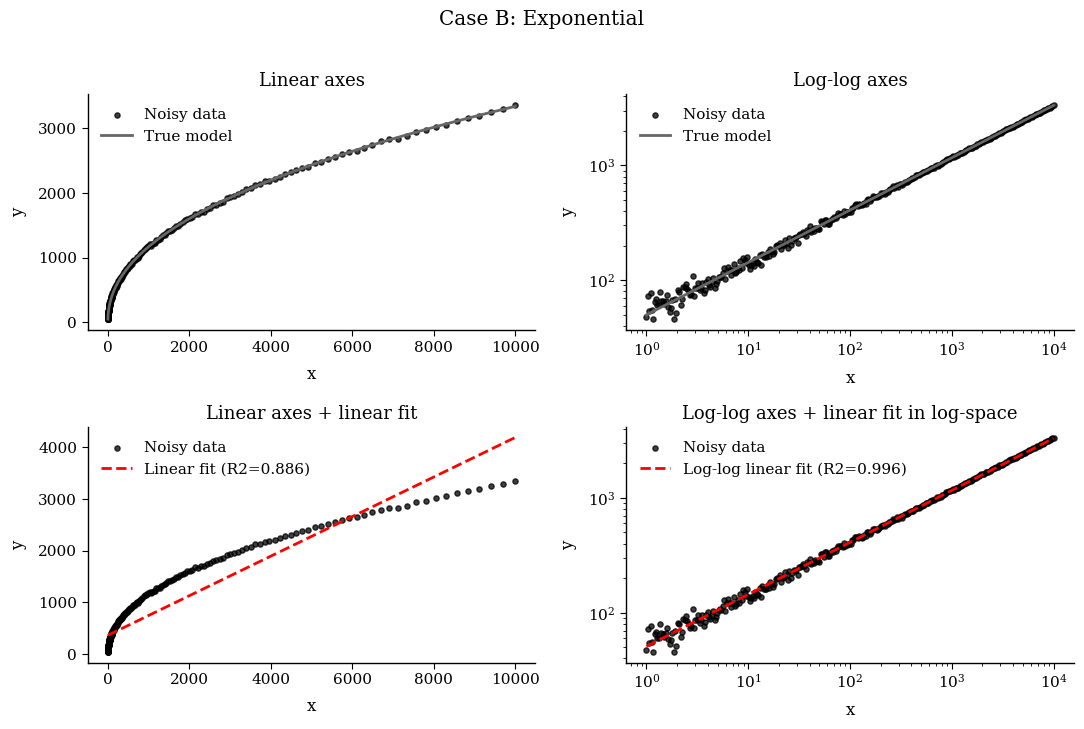

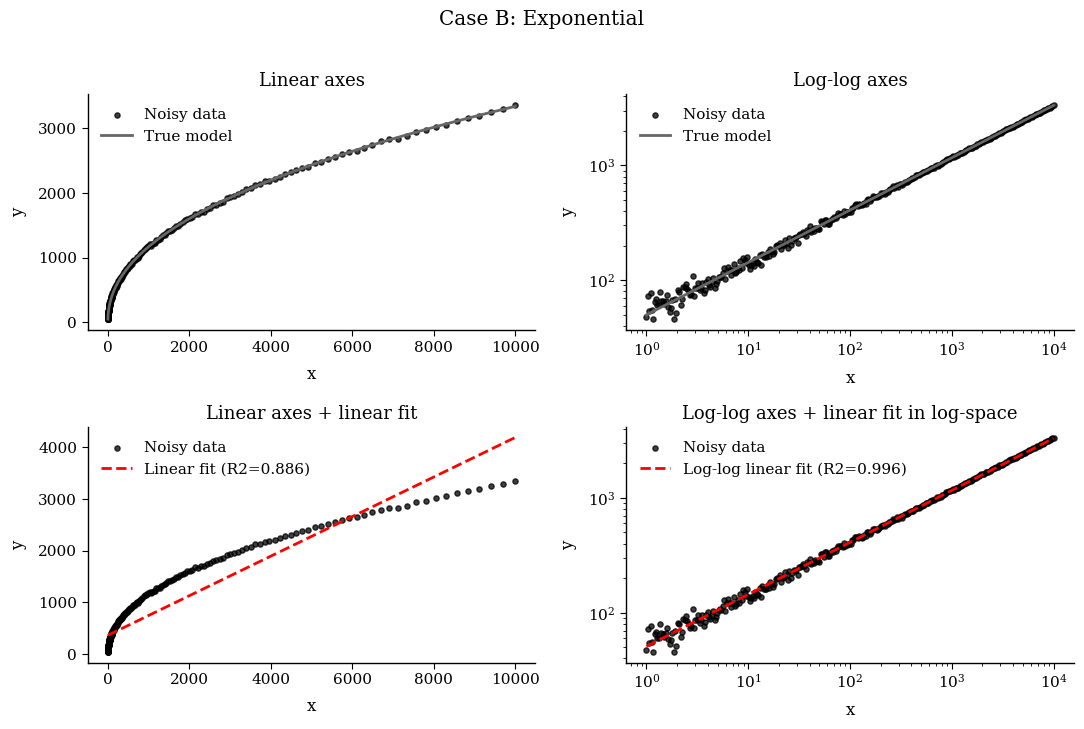

In [58]:
x_exp = np.logspace(0, 4, 300)
x_scaled = np.linspace(0, 6, 300)
A_exp = 50.0
k_exp = 0.7
y_true_exp = A_exp * np.exp(k_exp * x_scaled)
sigma_exp = 0.24 * y_true_exp.min()
assert np.all(y_true_exp - 4 * sigma_exp > 0)
eps_exp = rng.normal(0.0, sigma_exp, size=x_exp.size)
y_noisy_exp = y_true_exp + eps_exp
assert np.all(y_noisy_exp > 0)
fig_exp = plot_case_fit_figure(x_exp, y_true_exp, y_noisy_exp, "Case B: Exponential")
display(fig_exp)


## Case C: Cubic polynomial

The cubic model is not a power law, but over this chosen range the dominant cubic term can make the log-log view appear more line-like than linear axes suggest.


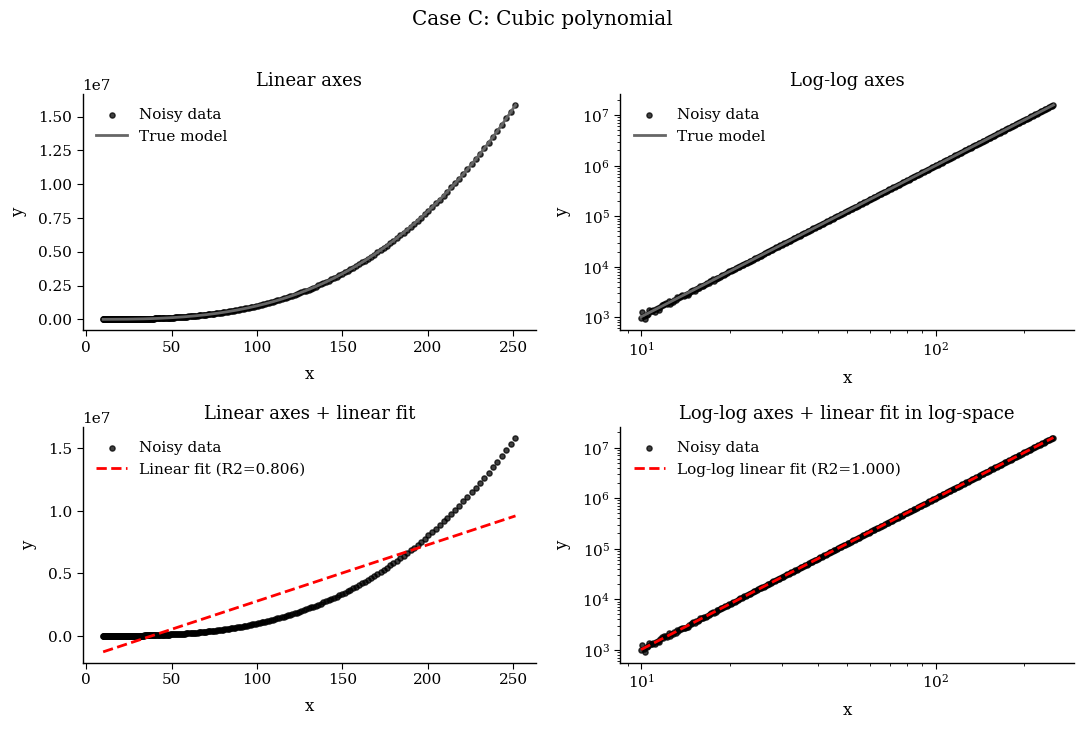

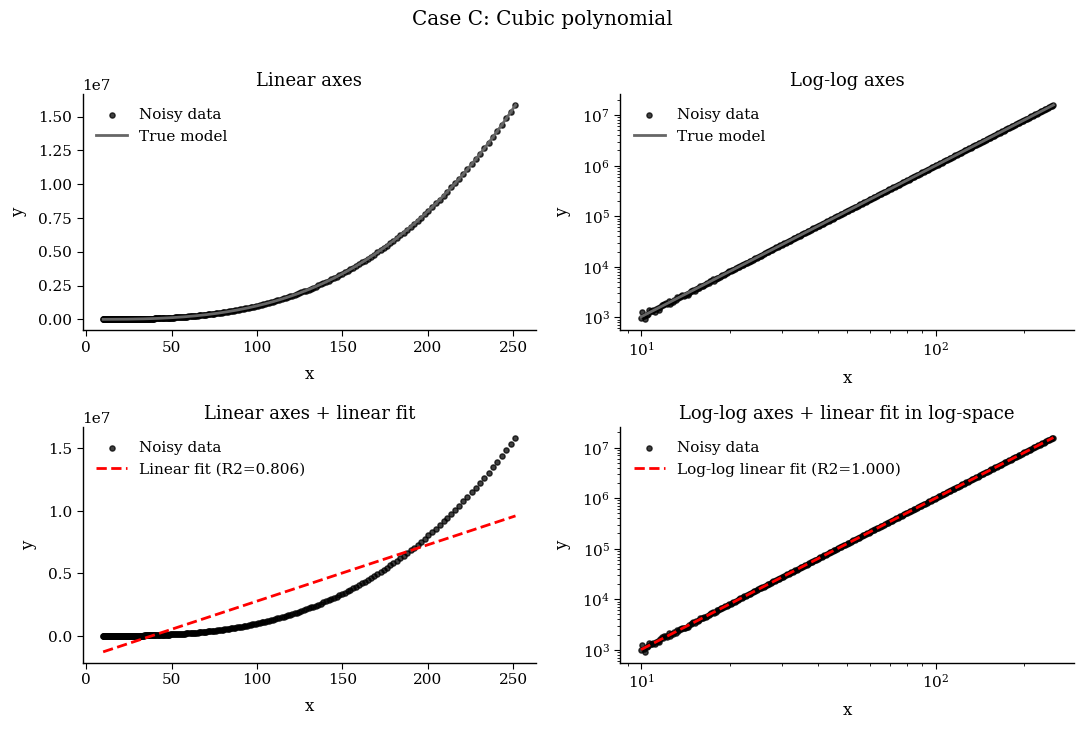

In [59]:
x_cubic = np.logspace(1.0, 2.4, 300)
a_c = 1.0
b_c = 0.10
c_c = 0.5
d_c = 5.0
y_true_cubic = a_c * x_cubic**3 + b_c * x_cubic**2 + c_c * x_cubic + d_c
sigma_cubic = 0.10 * y_true_cubic.min()
assert np.all(y_true_cubic - 4 * sigma_cubic > 0)
eps_cubic = rng.normal(0.0, sigma_cubic, size=x_cubic.size)
y_noisy_cubic = y_true_cubic + eps_cubic
assert np.all(y_noisy_cubic > 0)
fig_cubic = plot_case_fit_figure(x_cubic, y_true_cubic, y_noisy_cubic, "Case C: Cubic polynomial")
display(fig_cubic)


## Concluding Discussion

The power-law case is the aligned one for log-log fitting. The exponential and cubic cases show how smooth positive curves can still look straighter in log-log space over finite intervals, where fitted slopes should be treated as effective local behavior rather than universal laws.


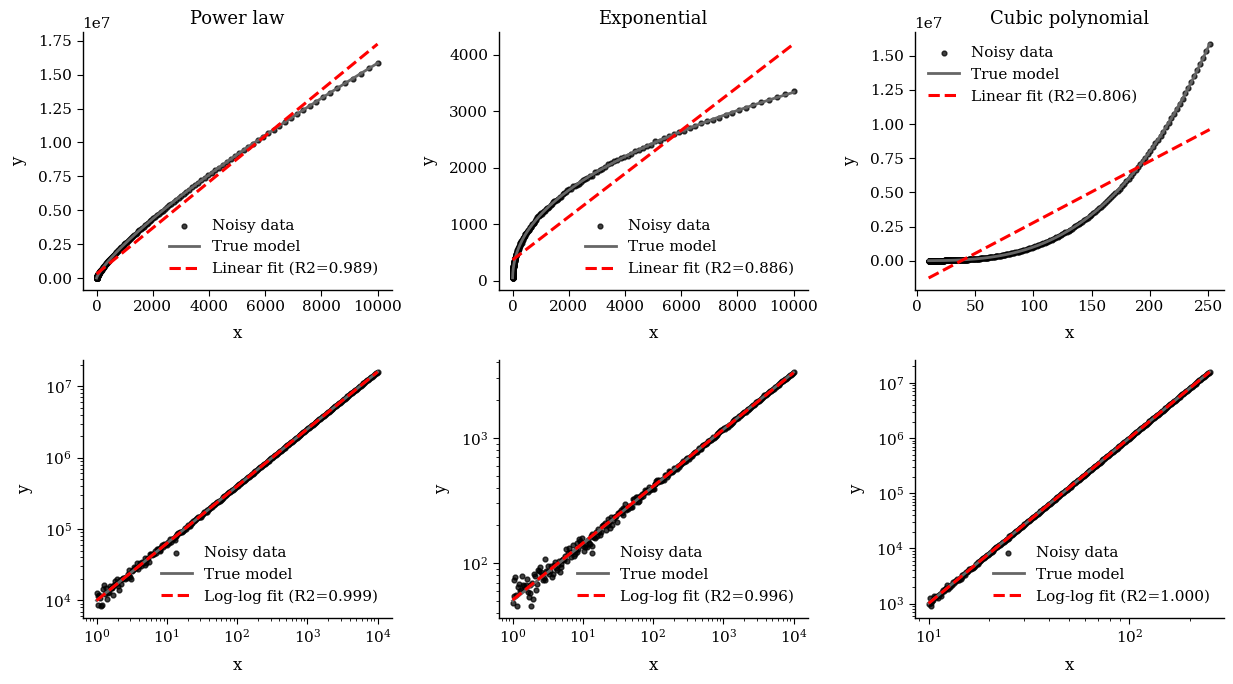

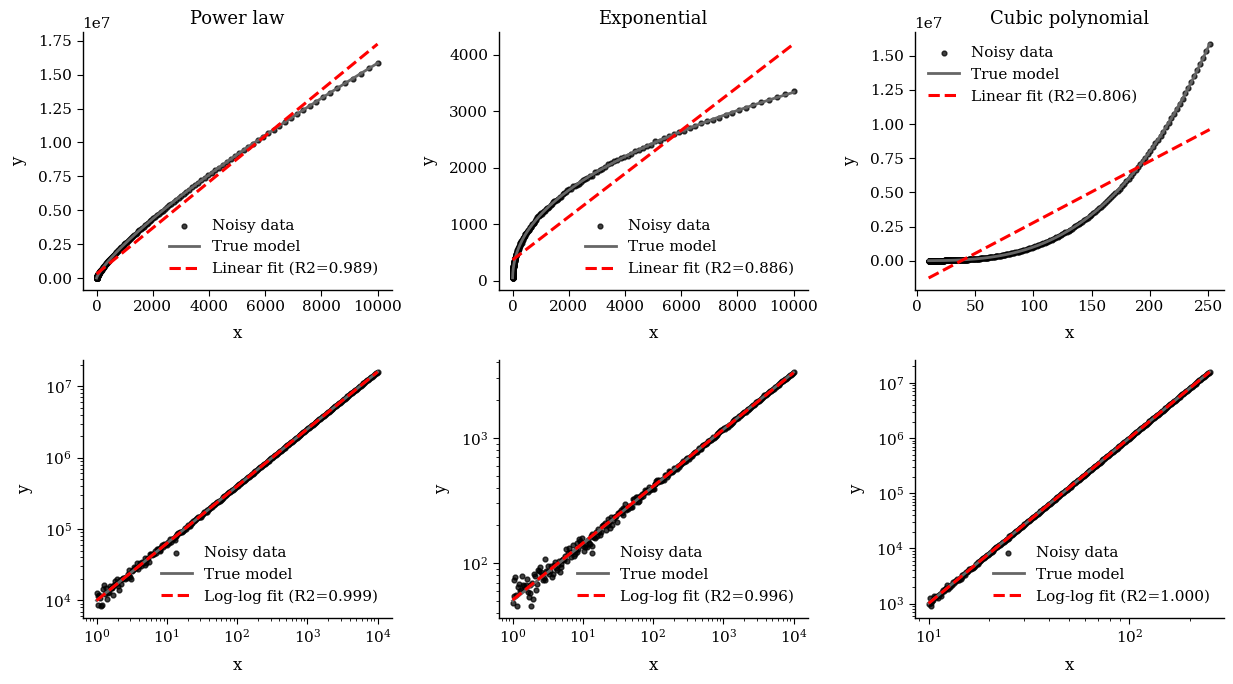

In [60]:
summary_cases = [("Power law", x_power, y_true_power, y_noisy_power), ("Exponential", x_exp, y_true_exp, y_noisy_exp), ("Cubic polynomial", x_cubic, y_true_cubic, y_noisy_cubic)]
fig_summary = plot_summary_figure(summary_cases)
display(fig_summary)


In [61]:
notebook_path = Path("loglog_illusion.ipynb") if Path("loglog_illusion.ipynb").exists() else Path("notebooks/loglog_illusion.ipynb")
outputs = generate_plot_figures(notebook_path=notebook_path, export_html=True, html_name="loglog_illusion.html")
outputs


/Users/filipeborges/.pyenv/versions/3.13.1/lib/python3.13/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


{'powerlaw_png': PosixPath('/Users/filipeborges/Documents/GitHub/everyLogIsLine/assets/loglog_powerlaw_fit.png'),
 'exponential_png': PosixPath('/Users/filipeborges/Documents/GitHub/everyLogIsLine/assets/loglog_exponential_fit.png'),
 'cubic_png': PosixPath('/Users/filipeborges/Documents/GitHub/everyLogIsLine/assets/loglog_cubic_fit.png'),
 'summary_png': PosixPath('/Users/filipeborges/Documents/GitHub/everyLogIsLine/assets/loglog_summary_cases.png'),
 'html': PosixPath('loglog_illusion.html')}